In [55]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import math

In [56]:
#file_path = "../root/out_94C50CE8-43B0-AF4D-A8AE-BE0C7EC09B80.root"
file_path = "../root/out_1ED582EB-116D-7D4A-ACD3-B1FDD875261D.root"
#file_path = "../root/out_pbpb.root"
#file_path = "../root/out_pbpb_test.root"

file = ROOT.TFile.Open(file_path)
tree = file.Get("jetTree")

n_entries = tree.GetEntries()
print(f"Number of entries in the tree: {n_entries}")

Number of entries in the tree: 136299


In [57]:
hist_form_time = ROOT.TH1F("hist_form_time", "Formation Time τ", 40, -10, 10)
hist_form_time.SetLineColor(ROOT.kBlack)
hist_form_time.SetLineWidth(2)

form_time_list = []
pt_list = []
pt_limit = 200 #300
eta_limit = 1


for entry in range(n_entries):
    tree.GetEntry(entry)
        
    for jet_i in range(len(tree.jet_pt)):
        if tree.jet_pt[jet_i] > pt_limit and abs(tree.jet_eta[jet_i]) < eta_limit:
            if (len(tree.tau_time[jet_i]) > 0):
                pt_list.append(tree.jet_pt[jet_i])
                first_form_time = tree.tau_time[jet_i][0]
                form_time_list.append(first_form_time)
                hist_form_time.Fill(np.log10(first_form_time))

In [58]:
hist_late_form_time = ROOT.TH1F("hist_late_form_time", "Late Formation Time τ", 40, -10, 10)  
hist_early_form_time = ROOT.TH1F("hist_early_form_time", "Early Formation Time τ", 40, -10, 10)
median_form_time = np.median(form_time_list)
min_form_time = np.min(form_time_list)
max_form_time = np.max(form_time_list)

form_time_25 = np.percentile(form_time_list, 25)
form_time_75 = np.percentile(form_time_list, 75)

print("Median: ", median_form_time)
print("Min: ", min_form_time)
print("Max: ", max_form_time)
print("25th Percentile: ", form_time_25)
print("75th Percentile: ", form_time_75)

for form_time in form_time_list:
    if form_time >= median_form_time:
        hist_late_form_time.Fill(np.log10(form_time))
    else:
        hist_early_form_time.Fill(np.log10(form_time))

hist_early_form_time.SetLineColor(ROOT.kRed)
hist_late_form_time.SetLineColor(ROOT.kBlue)
hist_early_form_time.SetLineWidth(2)
hist_late_form_time.SetLineWidth(2)

hist_form_time.GetXaxis().SetRangeUser(np.log10(median_form_time)-3, np.log10(median_form_time)+3)

Median:  2.852237886423619
Min:  0.016259670736897627
Max:  516555.473916406
25th Percentile:  0.5040667828648089
75th Percentile:  23.522027366116028


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


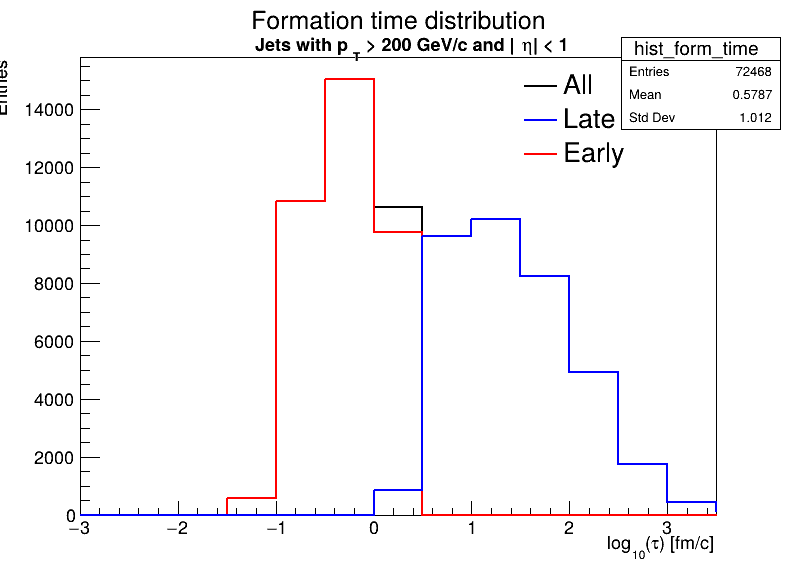

In [59]:
title = (
    f"Formation time distribution;log_{{10}}(#tau) [fm/c];Entries"
)
subtitle = f"Jets with p_{{T}} > {pt_limit:g} GeV/c and |#eta| < {eta_limit:g}"

hist_form_time.SetTitle(title)

# Draw with a subtitle using TLatex
canvas = ROOT.TCanvas("canvas", "Formation Time Distribution", 800, 600)
hist_form_time.Draw("HIST")
hist_early_form_time.Draw("HIST SAME")
hist_late_form_time.Draw("HIST SAME")

legend = ROOT.TLegend(0.65, 0.70, 0.88, 0.88)  # (x1,y1,x2,y2) in NDC
legend.SetBorderSize(0)
legend.SetFillStyle(0)  # transparent
legend.AddEntry(hist_form_time, "All", "l")
legend.AddEntry(hist_late_form_time, "Late", "l")
legend.AddEntry(hist_early_form_time, "Early", "l")
legend.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.035)
latex.DrawLatex(0.32, 0.91, subtitle)

canvas.Update()
canvas.Draw()

In [60]:
q95 = np.percentile(pt_list, 99)
hist_jet_pt = ROOT.TH1F("hist_jet_pt", "Jet pT Distribution", 100, pt_limit, q95)
hist_late_jet_pt = ROOT.TH1F("hist_late_jet_pt", "Late Jet pT Distribution", 100, pt_limit, q95)
hist_early_jet_pt = ROOT.TH1F("hist_early_jet_pt", "Early Jet pT Distribution", 100, pt_limit, q95)

for entry in range(n_entries):
    tree.GetEntry(entry)
        
    for jet_i in range(len(tree.jet_pt)):
        if tree.jet_pt[jet_i] > pt_limit and abs(tree.jet_eta[jet_i]) < eta_limit:
            if (len(tree.tau_time[jet_i]) > 0):
                first_form_time = tree.tau_time[jet_i][0]
                hist_jet_pt.Fill(tree.jet_pt[jet_i])
                if first_form_time >= median_form_time:
                    hist_late_jet_pt.Fill(tree.jet_pt[jet_i])
                else:
                    hist_early_jet_pt.Fill(tree.jet_pt[jet_i])

hist_jet_pt.SetLineColor(ROOT.kBlack)
hist_jet_pt.SetLineWidth(2)
hist_early_jet_pt.SetLineColor(ROOT.kRed)
hist_late_jet_pt.SetLineColor(ROOT.kBlue)
hist_early_jet_pt.SetLineWidth(2)
hist_late_jet_pt.SetLineWidth(2)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_pt


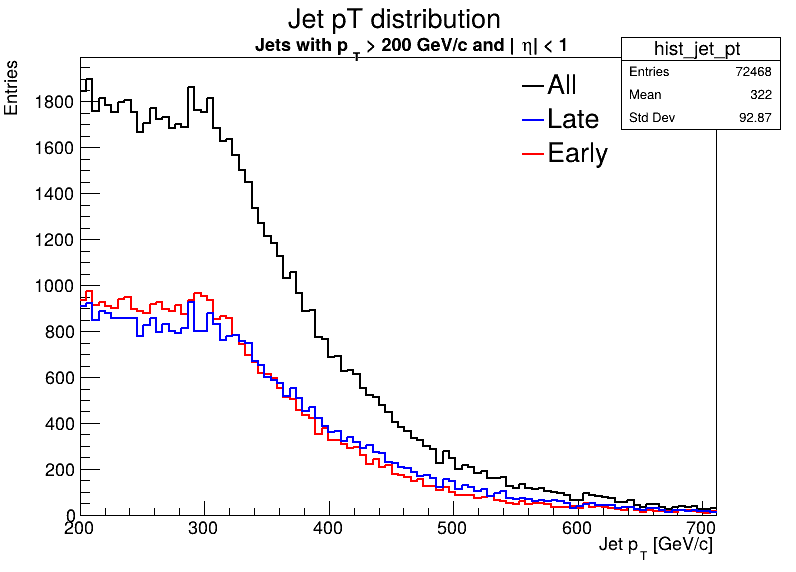

In [61]:
title = (
    f"Jet pT distribution;Jet p_{{T}} [GeV/c];Entries"
)
subtitle = f"Jets with p_{{T}} > {pt_limit:g} GeV/c and |#eta| < {eta_limit:g}"

hist_jet_pt.SetTitle(title)

# Draw with a subtitle using TLatex
canvas_pt = ROOT.TCanvas("canvas_pt", "Jet pT Distribution", 800, 600)
hist_jet_pt.Draw("HIST")
hist_early_jet_pt.Draw("HIST SAME")
hist_late_jet_pt.Draw("HIST SAME")

legend = ROOT.TLegend(0.65, 0.70, 0.8, 0.88)  # (x1,y1,x2,y2) in NDC
legend.SetBorderSize(0)
legend.SetFillStyle(0)  # transparent
legend.AddEntry(hist_form_time, "All", "l")
legend.AddEntry(hist_late_form_time, "Late", "l")
legend.AddEntry(hist_early_form_time, "Early", "l")
legend.Draw()

latex_pt = ROOT.TLatex()
latex_pt.SetNDC(True)
latex_pt.SetTextSize(0.035)
latex_pt.DrawLatex(0.32, 0.91, subtitle)
canvas_pt.Update()
canvas_pt.Draw()

In [62]:
hist_psi12 = ROOT.TH1F("hist_psi12", "Jet ψ_{12} Distribution", 40, -np.pi,np.pi)
hist_late_psi12 = ROOT.TH1F("hist_late_psi12", "Late Jet ψ_{12} Distribution", 40, -np.pi,np.pi)
hist_early_psi12 = ROOT.TH1F("hist_early_psi12", "Early Jet ψ_{12} Distribution", 40, -np.pi,np.pi)

hist_lund = ROOT.TH2F("prim_lund", "Primary Lund", 100, 0, 10, 100, -10, 10)
hist_early_lund = ROOT.TH2F("early_lund", "Early Primary Lund", 100, 0, 10, 100, -10, 10)
hist_late_lund = ROOT.TH2F("late_lund", "Late Primary Lund", 100, 0, 10, 100, -10, 10)

max_x = -float('inf')
min_x = float('inf')
max_y = -float('inf')
min_y = float('inf')


error_count = 0
for entry in range(n_entries):
    tree.GetEntry(entry)
        
    for jet_i in range(len(tree.jet_pt)):
        if tree.jet_pt[jet_i] > pt_limit and abs(tree.jet_eta[jet_i]) < eta_limit:
            if (len(tree.tau_time[jet_i]) > 0):
                first_form_time = tree.tau_time[jet_i][0]
                '''
                if not math.isfinite(float(first_form_time)):
                    error_count += 1
                    continue
                '''
                hist_psi12.Fill(tree.lund_psi12[jet_i])

                for i in range(len(tree.lund_coords_x_sd[jet_i])):
                    x = tree.lund_coords_x_sd[jet_i][i]
                    y = tree.lund_coords_y_sd[jet_i][i]
                    hist_lund.Fill(x, y)

                    if x > max_x:
                        max_x = x
                    if x < min_x:
                        min_x = x
                    if y > max_y:
                        max_y = y
                    if y < min_y:
                        min_y = y

                    if first_form_time >= median_form_time:
                        hist_late_lund.Fill(x, y)
                    elif first_form_time < median_form_time:
                        hist_early_lund.Fill(x, y)

                if first_form_time >= median_form_time:
                    hist_late_psi12.Fill(tree.lund_psi12[jet_i])
                elif first_form_time < median_form_time:
                    hist_early_psi12.Fill(tree.lund_psi12[jet_i])
                #else:
                #    print("Unexpected case for formation time: ", first_form_time)
            else:
                error_count += 1

if min_x < 0:
    min_x = 0
if max_x > 7:
    max_x = 7
if min_y < -4:
    min_y = -4
if max_y > 7:
    max_y = 7

hist_lund.GetXaxis().SetRangeUser(min_x, max_x)
hist_lund.GetYaxis().SetRangeUser(min_y, max_y)

hist_early_lund.GetXaxis().SetRangeUser(min_x, max_x)
hist_early_lund.GetYaxis().SetRangeUser(min_y, max_y)

hist_late_lund.GetXaxis().SetRangeUser(min_x, max_x)
hist_late_lund.GetYaxis().SetRangeUser(min_y, max_y)

print(f"Entries with no formation time: {error_count}")
hist_psi12.SetLineColor(ROOT.kBlack)
hist_psi12.SetLineWidth(2)
hist_early_psi12.SetLineColor(ROOT.kRed)
hist_early_psi12.SetLineWidth(2)
hist_late_psi12.SetLineColor(ROOT.kBlue)
hist_late_psi12.SetLineWidth(2)

Entries with no formation time: 855


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_psi12


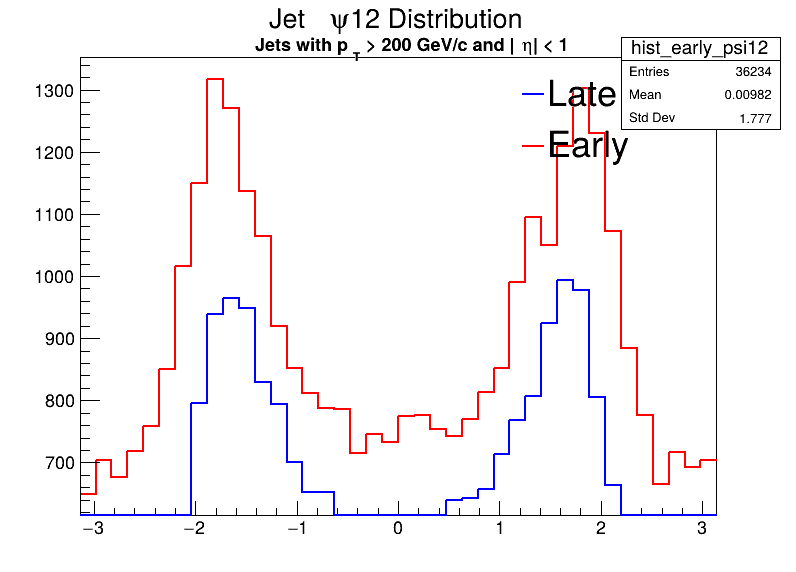

In [63]:
title = (
    f"Jet #psi12 Distribution"
)
subtitle = f"Jets with p_{{T}} > {pt_limit:g} GeV/c and |#eta| < {eta_limit:g}"

hist_psi12.SetTitle(title)
# Draw with a subtitle using TLatex
canvas_psi12 = ROOT.TCanvas("canvas_psi12", "Jet ψ12 Distribution", 800, 600)
#hist_psi12.Draw("HIST")

hist_early_psi12.SetTitle(title)
hist_early_psi12.Draw("HIST SAME")
hist_late_psi12.Draw("HIST SAME")

legend = ROOT.TLegend(0.65, 0.70, 0.8, 0.88)  # (x1,y1,x2,y2) in NDC
legend.SetBorderSize(0)
legend.SetFillStyle(0)  # transparent
#legend.AddEntry(hist_form_time, "All", "l")
legend.AddEntry(hist_late_form_time, "Late", "l")
legend.AddEntry(hist_early_form_time, "Early", "l")
legend.Draw()

latex_psi12 = ROOT.TLatex()
latex_psi12.SetNDC(True)
latex_psi12.SetTextSize(0.035)
latex_psi12.DrawLatex(0.32, 0.91, subtitle)
canvas_psi12.Update()
canvas_psi12.Draw()


Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_lund


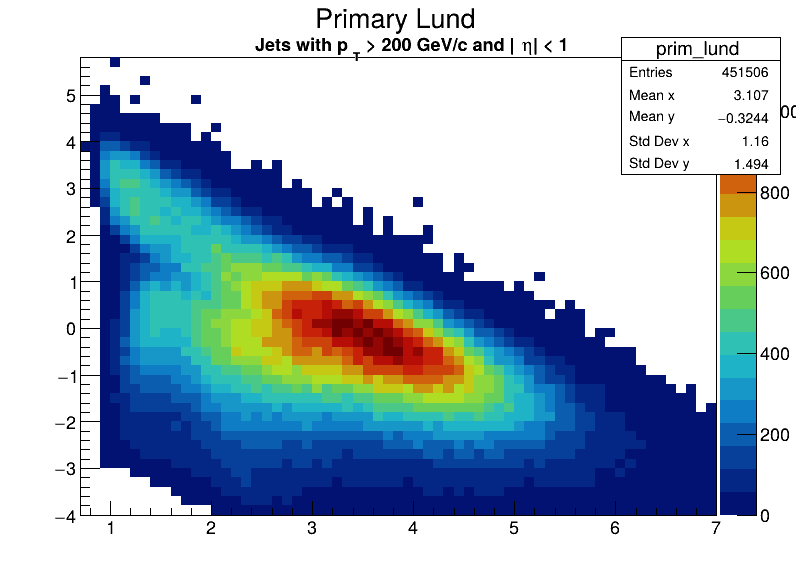

In [64]:
ROOT.gStyle.SetPalette(ROOT.kRainbow)
subtitle = f"Jets with p_{{T}} > {pt_limit:g} GeV/c and |#eta| < {eta_limit:g}"

canvas_lund = ROOT.TCanvas("canvas_lund", "Primary Lund Plane", 800, 600)
hist_lund.Draw("COLZ")

latex_lund = ROOT.TLatex()
latex_lund.SetNDC(True)
latex_lund.SetTextSize(0.035)
latex_lund.DrawLatex(0.32, 0.91, subtitle)

canvas_lund.Update()
canvas_lund.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_early_lund


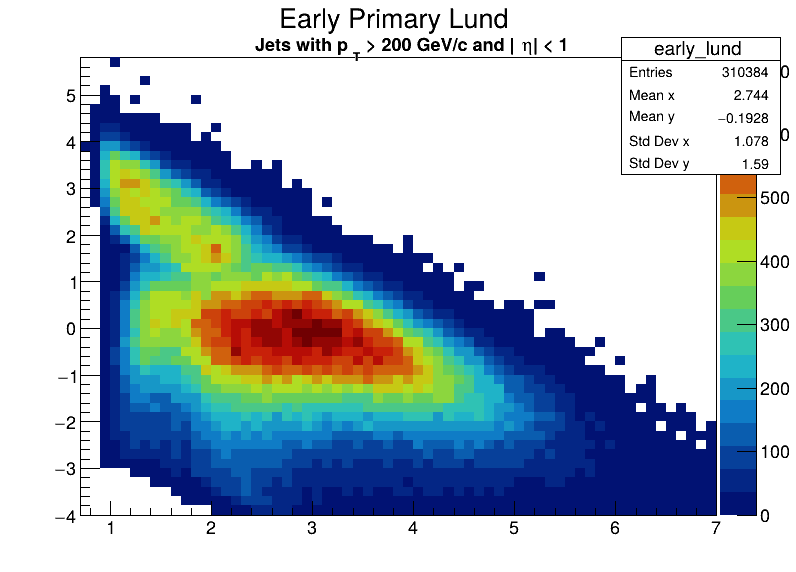

In [65]:
canvas_early_lund = ROOT.TCanvas("canvas_early_lund", "Early Primary Lund Plane", 800, 600)
hist_early_lund.Draw("COLZ")

latex_early_lund = ROOT.TLatex()
latex_early_lund.SetNDC(True)
latex_early_lund.SetTextSize(0.035)
latex_early_lund.DrawLatex(0.32, 0.91, subtitle)

canvas_early_lund.Update()
canvas_early_lund.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_late_lund


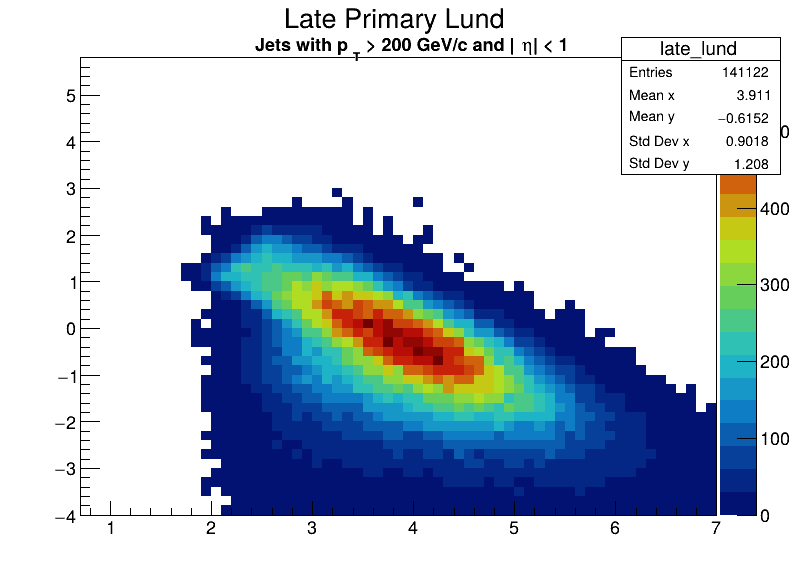

In [66]:
canvas_late_lund = ROOT.TCanvas("canvas_late_lund", "Late Primary Lund Plane", 800, 600)
hist_late_lund.Draw("COLZ")
latex_late_lund = ROOT.TLatex()
latex_late_lund.SetNDC(True)
latex_late_lund.SetTextSize(0.035)
latex_late_lund.DrawLatex(0.32, 0.91, subtitle)
canvas_late_lund.Update()
canvas_late_lund.Draw()